# Train a PyTorch classifier on EEG

*medusa-kernel 2.0*

`medusa.ml.torch_models` brings deep learning to medusa-kernel. It provides:

- **backbones** — headless EEG feature extractors (`EEGNet`, `EEGInception`,
  `EEGInceptionV2`, `EEGSym`), pure `torch.nn.Module`s with no
  classification head, and
- **estimators** — `TorchClassifier`, a plain **scikit-learn** classifier
  (`fit` / `predict` / `predict_proba` / `score`) that wraps a backbone,
  trains it with PyTorch Lightning under the hood, and infers the head size
  from your labels.

In this notebook you will:

- synthesise a 2-class ERP-like dataset with `medusa.signal.generators`,
- train an `EEGNet` classifier on it,
- evaluate it (accuracy, confusion matrix, ROC curve),
- save the trained model to one portable file and reload it.

> PyTorch and Lightning are **optional** dependencies — medusa-kernel does
> not install them automatically, because the right build depends on your
> CUDA / CPU setup. Install them to match your hardware (see
> [pytorch.org](https://pytorch.org/get-started/)).

## Imports

<div class="alert alert-block alert-danger">
Important: execute the following cell <b>only</b> if you're using Google Colab!
</div>

In [1]:
!pip install medusa-kernel "torch==2.12" "lightning==2.6"

Import the modules used in this notebook.

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import medusa_style
import medusa.plots as mp
from medusa.core.data import ChannelSet
from medusa.signal.generators import EEGSignalGenerator
from medusa.ml.torch_models.backbones import EEGNet
from medusa.ml.torch_models.classification import TorchClassifier

medusa_style.apply()
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
np.random.seed(0)
torch.manual_seed(0)
print('> torch', torch.__version__)

W0629 10:48:05.531000 40968 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


> torch 2.12.0+cu126


## A synthetic 2-class ERP dataset

We build a binary classification problem that mimics an **oddball / ERP**
paradigm:

- **non-target** epochs are pure background EEG (`1/f` + rhythms),
- **target** epochs additionally contain a **P300-like** positive
  deflection around 300 ms, strongest over central-posterior channels.

Each epoch is `(n_samples, n_channels)`; the classifier input `X` stacks
them into `(n_epochs, n_samples, n_channels)`, exactly the shape
`medusa.signal.segmentation` produces from a continuous recording.

In [3]:
fs = 128.0
epoch_s = 0.9                                  # epoch length (s)
samples = int(epoch_s * fs)
channels = ['Fz', 'Cz', 'Pz', 'C3', 'C4', 'P3', 'P4', 'Oz']
n_cha = len(channels)
channel_set = ChannelSet().add_unipolar_eeg_channels(channels)
post = [channels.index(c) for c in ('Cz', 'Pz', 'P3', 'P4', 'Oz')]
te = np.arange(samples) / fs

def make_epochs(n, target, seed):
    """n background epochs; if target, add a central-posterior P300."""
    gen = EEGSignalGenerator(fs=fs, oscillations=[(10.0, 6.0)],
                             background_amplitude=10.0, seed=seed)
    X = np.stack([gen.get_chunk(epoch_s, n_cha) for _ in range(n)])
    if target:
        p300 = np.exp(-((te - 0.3) ** 2) / (2 * 0.06 ** 2))   # bump at 300 ms
        X[:, :, post] += 5.0 * p300[None, :, None]
    return X

n_per_class = 150
X = np.concatenate([make_epochs(n_per_class, False, 1),
                    make_epochs(n_per_class, True, 2)])
y = np.array(['non-target'] * n_per_class + ['target'] * n_per_class)
print(f'> X shape (epochs, samples, channels): {X.shape}')
print(f'> classes: {np.unique(y)}')

> X shape (epochs, samples, channels): (300, 115, 8)
> classes: ['non-target' 'target']


### Inspect the data

The mean (grand-average) waveform of each class at **Pz** shows the
synthetic P300 the network must learn — a clear positive peak around 300 ms
for targets only. The shaded band is the 95% CI across epochs.

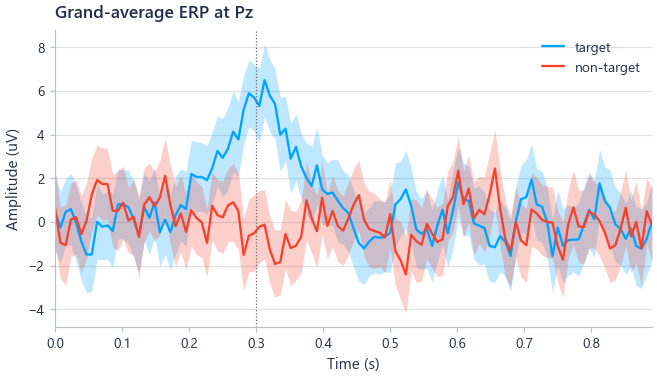

In [4]:
pz = channels.index('Pz')
fig, ax = plt.subplots(figsize=(7, 3.5))
mp.plot_shaded_line(X[y == 'target', :, pz], ax, x=te, error='ci95',
                    color=medusa_style.categorical_color(0), label='target')
mp.plot_shaded_line(X[y == 'non-target', :, pz], ax, x=te, error='ci95',
                    color=medusa_style.categorical_color(1), label='non-target')
ax.axvline(0.3, color='0.4', lw=0.8, ls=':')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (uV)')
ax.set_title('Grand-average ERP at Pz')
plt.show()

## Train / test split

We hold out 25% of the epochs for testing, stratified by class so both
splits keep the 50/50 balance.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0)
print(f'> train: {X_train.shape[0]} epochs   test: {X_test.shape[0]} epochs')

> train: 225 epochs   test: 75 epochs


## Build and train the classifier

We instantiate an `EEGNet` backbone sized for our epochs (`n_cha`,
`samples`) and wrap it in a `TorchClassifier`. The estimator owns the
training loop; you only set the hyperparameters:

- `max_epochs`, `batch_size`, `lr` — the usual knobs,
- `val_split` — fraction held out internally for early stopping
  (`patience`) and best-checkpoint restore,
- `device='auto'` — uses a GPU if one is available, else the CPU.

`fit` sizes the softmax head from `np.unique(y)`, so there is nothing else
to configure.

In [ ]:
backbone = EEGNet(n_cha=n_cha, samples=samples, kern_length=int(fs // 2))
clf = TorchClassifier(backbone, max_epochs=40, batch_size=32, lr=1e-3,
                      val_split=0.2, patience=8, device='auto', verbose='epoch')
clf.fit(X_train, y_train)
print(f'> training finished. classes_: {clf.classes_}')

## Evaluate

`score` returns accuracy; `predict` and `predict_proba` give labels and
class probabilities (columns ordered as `clf.classes_`). We summarise
performance with a confusion matrix and a ROC curve.

In [7]:
acc = clf.score(X_test, y_test)
y_pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)
print(f'> Test accuracy: {acc:.3f}')

> Test accuracy: 0.920


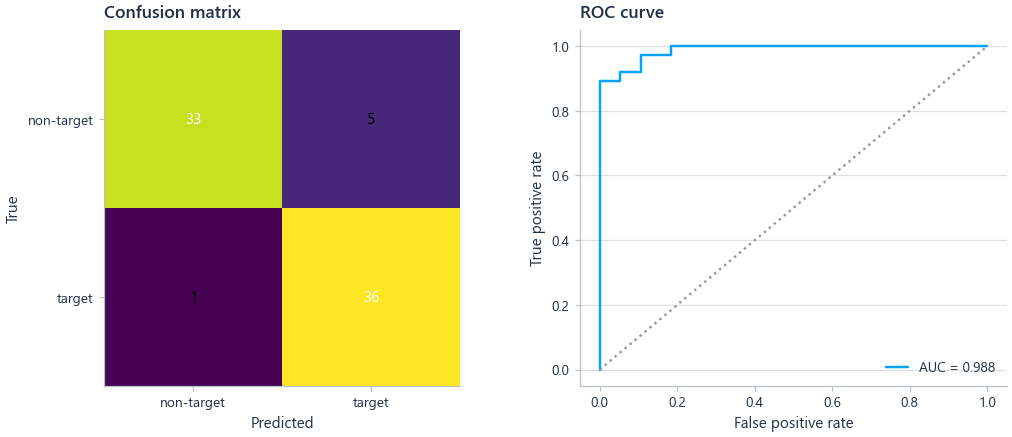

In [8]:
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.2))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
im = ax_cm.imshow(cm, cmap=medusa_style.mpl.sequential_cmap())
ax_cm.grid(False)
ax_cm.set_xticks(range(len(clf.classes_)), labels=clf.classes_)
ax_cm.set_yticks(range(len(clf.classes_)), labels=clf.classes_)
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
ax_cm.set_title('Confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(j, i, cm[i, j], ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black')

# ROC curve (positive class = 'target')
pos = list(clf.classes_).index('target')
fpr, tpr, _ = roc_curve(y_test == 'target', proba[:, pos])
ax_roc.plot(fpr, tpr, color=medusa_style.categorical_color(0),
            label=f'AUC = {auc(fpr, tpr):.3f}')
ax_roc.plot([0, 1], [0, 1], color='0.6', ls=':')
ax_roc.set_xlabel('False positive rate'); ax_roc.set_ylabel('True positive rate')
ax_roc.set_title('ROC curve'); ax_roc.legend(loc='lower right')

mp.save_figure(fig, RESULTS / 'eegnet_evaluation.png')
plt.show()

## Save and reload the model

A fitted `TorchClassifier` is saved as a single, portable file — a
`config + state_dict` bundle (never a raw module pickle), so it reloads
across devices and torch versions. The reloaded model predicts
identically.

In [9]:
model_path = RESULTS / 'eegnet_erp.pkl'
clf.save(str(model_path))

clf_loaded = TorchClassifier.load(str(model_path))
reloaded_acc = clf_loaded.score(X_test, y_test)
same = np.array_equal(clf.predict(X_test), clf_loaded.predict(X_test))
print(f'> saved to {model_path.name} '
      f'({model_path.stat().st_size // 1024} KB)')
print(f'> reloaded accuracy: {reloaded_acc:.3f}   identical predictions: {same}')

> saved to eegnet_erp.pkl (12 KB)
> reloaded accuracy: 0.920   identical predictions: True


## Summary and next steps

In this tutorial you:

- built a 2-class ERP dataset with `medusa.signal.generators`,
- trained an `EEGNet` classifier with `TorchClassifier` (a drop-in sklearn
  estimator),
- evaluated it with accuracy, a confusion matrix and a ROC curve,
- saved and reloaded the model from one portable file.

Where to go next:

- swap in another backbone — `EEGInception`, `EEGInceptionV2` or `EEGSym` —
  by changing a single line,
- because `TorchClassifier` is a scikit-learn estimator, use
  `sklearn.model_selection.cross_val_score` / `GridSearchCV` directly,
- train on a **real** recording: load one with the *Loading legacy MEDUSA
  data* tutorial and epoch it with `medusa.signal.segmentation`.

See you in the next MEDUSA tutorial!

## References

1. Lawhern, V. J., Solon, A. J., Waytowich, N. R., Gordon, S. M., Hung,
   C. P., & Lance, B. J. (2018). *EEGNet: a compact convolutional neural
   network for EEG-based brain-computer interfaces.* J. Neural Eng., 15(5),
   056013.